In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import numpy as np

sys.path.append("..")
from utils.psf_correction import PSFCorrection

from models.psf import KingPSF

import matplotlib.pyplot as plt

In [5]:
nside = 128

kp = KingPSF()

psf0 = PSFCorrection(delay_compute=True, num_f_bins=15, nside=nside, f_trunc=0.01)
psf0.psf_r_func = lambda r: kp.psf_fermi_r(r)
psf0.sample_psf_max = 10.0 * kp.spe * (kp.score + kp.stail) / 2.0
psf0.psf_samples = 10000
psf0.psf_tag = f"Fermi_PSF_2GeV2_nside{nside}"
psf0.make_or_load_psf_corr(force_recompute=True)

In [4]:
psf1 = PSFCorrection(
    delay_compute=True, num_f_bins='nonuni', nside=nside, f_trunc=0.00,
    n_psf=100000
)
psf1.psf_r_func = lambda r: kp.psf_fermi_r(r)
psf1.sample_psf_max = 10.0 * kp.spe * (kp.score + kp.stail) / 2.0
psf1.psf_samples = 10000
psf1.psf_tag = f"Fermi_PSF_2GeV2_nside{nside}"
psf1.make_or_load_psf_corr(force_recompute=True)

In [8]:
# delta psf
psf1 = PSFCorrection(
    delay_compute=True, num_f_bins=60, nside=nside, f_trunc=0.00,
    psf_sigma_deg=1e-6,
    n_psf=100000
)
psf1.sample_psf_max = 1e-6
psf1.psf_samples = 10000
psf1.psf_tag = f"Fermi_PSF_2GeV2_nside{nside}"
psf1.make_or_load_psf_corr(force_recompute=True)

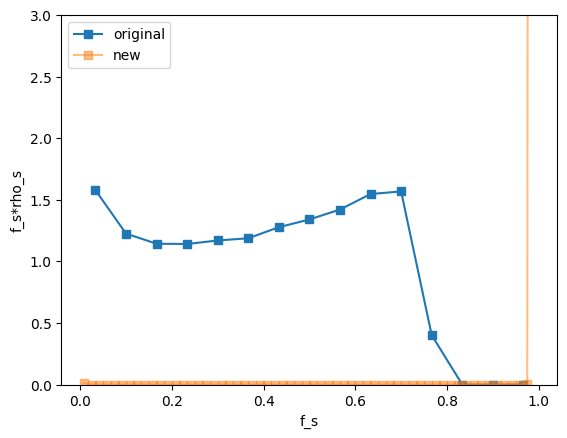

In [9]:
fig, ax = plt.subplots()
ax.plot(psf0.f_ary, psf0.f_ary*psf0.rho_ary, 's-', label='original')
ax.plot(psf1.f_ary, psf1.f_ary*psf1.rho_ary, 's-', alpha=0.5, label='new')
ax.set(xlabel='f_s', ylabel='f_s*rho_s')
ax.set(ylim=(0, 3))
ax.legend();

In [10]:
psf1.f_ary, psf1.f_ary*psf1.rho_ary

(array([0.00833333, 0.025     , 0.04166667, 0.05833333, 0.075     ,
        0.09166667, 0.10833333, 0.125     , 0.14166667, 0.15833333,
        0.175     , 0.19166667, 0.20833333, 0.225     , 0.24166667,
        0.25833333, 0.275     , 0.29166667, 0.30833333, 0.325     ,
        0.34166667, 0.35833333, 0.375     , 0.39166667, 0.40833333,
        0.425     , 0.44166667, 0.45833333, 0.475     , 0.49166667,
        0.50833333, 0.525     , 0.54166667, 0.55833333, 0.575     ,
        0.59166667, 0.60833333, 0.625     , 0.64166667, 0.65833333,
        0.675     , 0.69166667, 0.70833333, 0.725     , 0.74166667,
        0.75833333, 0.775     , 0.79166667, 0.80833333, 0.825     ,
        0.84166667, 0.85833333, 0.875     , 0.89166667, 0.90833333,
        0.925     , 0.94166667, 0.95833333, 0.975     , 0.99166667]),
 array([1.11004623e-02, 3.02464913e-05, 0.00000000e+00, 3.52875731e-05,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        8.56983919e-05, 0.00000000e+00

In [12]:
print(
    'original',
    np.sum(psf0.df_rho_div_f_ary * psf0.f_ary),
    np.sum(psf0.df_rho_div_f_ary * psf0.f_ary**2)
)
print(
    'deltapsf',
    np.sum(psf1.df_rho_div_f_ary * psf1.f_ary),
    np.sum(psf1.df_rho_div_f_ary * psf1.f_ary**2)
)

original 6.122691860213155 1.0
deltapsf 1.0304677107363365 1.0


In [14]:
12*128**2

196608